# Objectives
Dataset: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
1. Diabetes Classification (Y/N)
2. Feature importance and explainability
3. Early diabetes risk prediction
4. Clustering for risk group 


# Libraries and dependencies

In [20]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt


# Load dataset

In [22]:
# Define the path correctly
dataset_path = "data/diabetes.csv"

# Load the CSV into a DataFrame
df = pd.read_csv(dataset_path)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [23]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [25]:
# Check for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [26]:
# Distribution of the 2 classes in Outcome column
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

In [27]:
# List of continuous numerical columns
X = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

In [28]:
def plot_histograms(df, columns, title='Histograms for Numerical Columns'):
    """
    Plots histograms for the specified numerical columns in a DataFrame.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the data.
        columns (list): List of numerical column names to plot.
        title (str): Title for the entire figure.
    """
    num_cols = len(columns)
    n_rows = (num_cols // 3) + (num_cols % 3 > 0)
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    fig.suptitle(title, fontsize=16)
    
    axes = axes.flatten()
    
    for i, column in enumerate(columns):
        axes[i].hist(df[column].dropna(), bins=30, edgecolor='black', color='#4682B4')
        axes[i].set_title(column, fontsize = 14)
        axes[i].set_xlabel(column, fontsize = 14)
        axes[i].set_ylabel('Frequency')
    
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


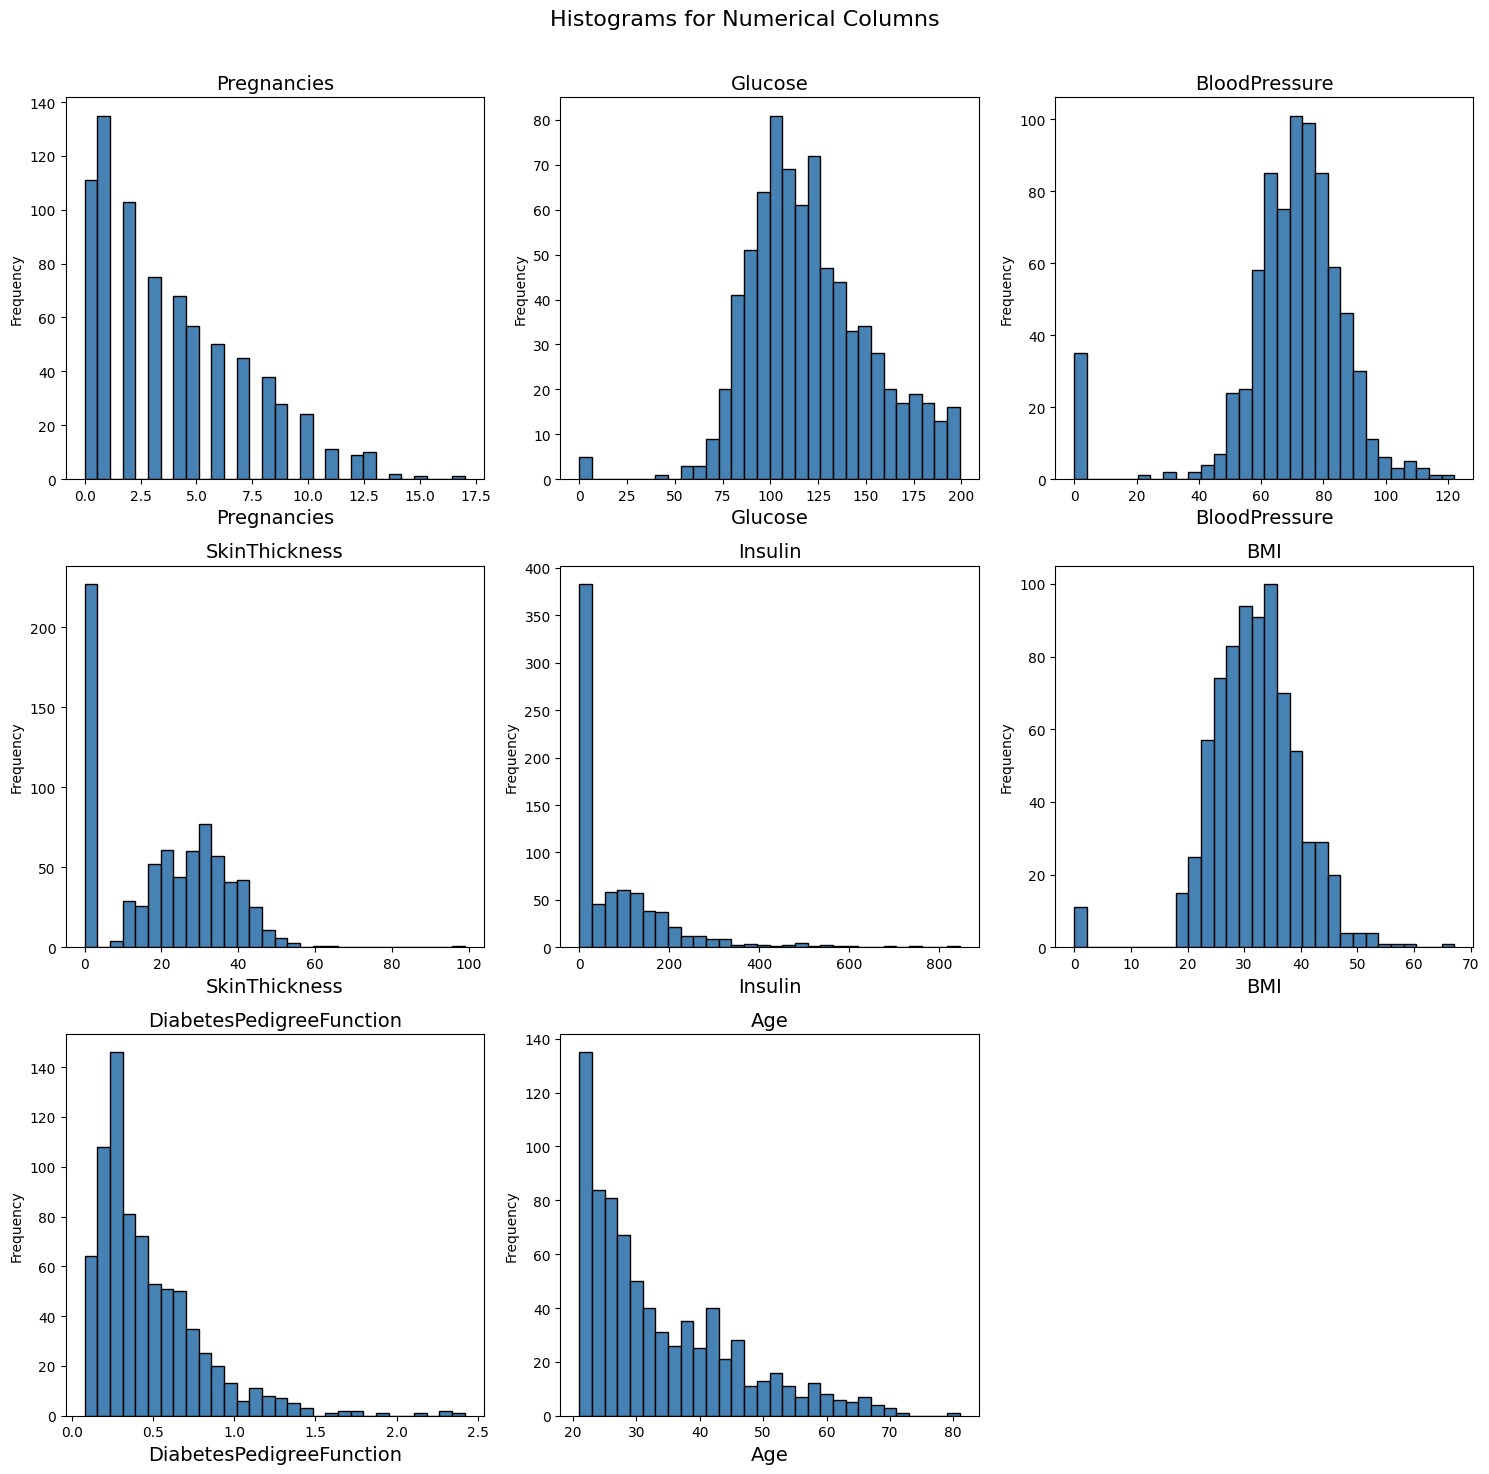

In [29]:
plot_histograms(df, X, title='Histograms for Numerical Columns')

# Replace 0 in appropriate columns with median

In [30]:
# List of columns where 0 is invalid
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN first
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

# Impute NaNs with median based on Outcome (0 = non-diabetic, 1 = diabetic)
for col in invalid_zero_cols:
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))


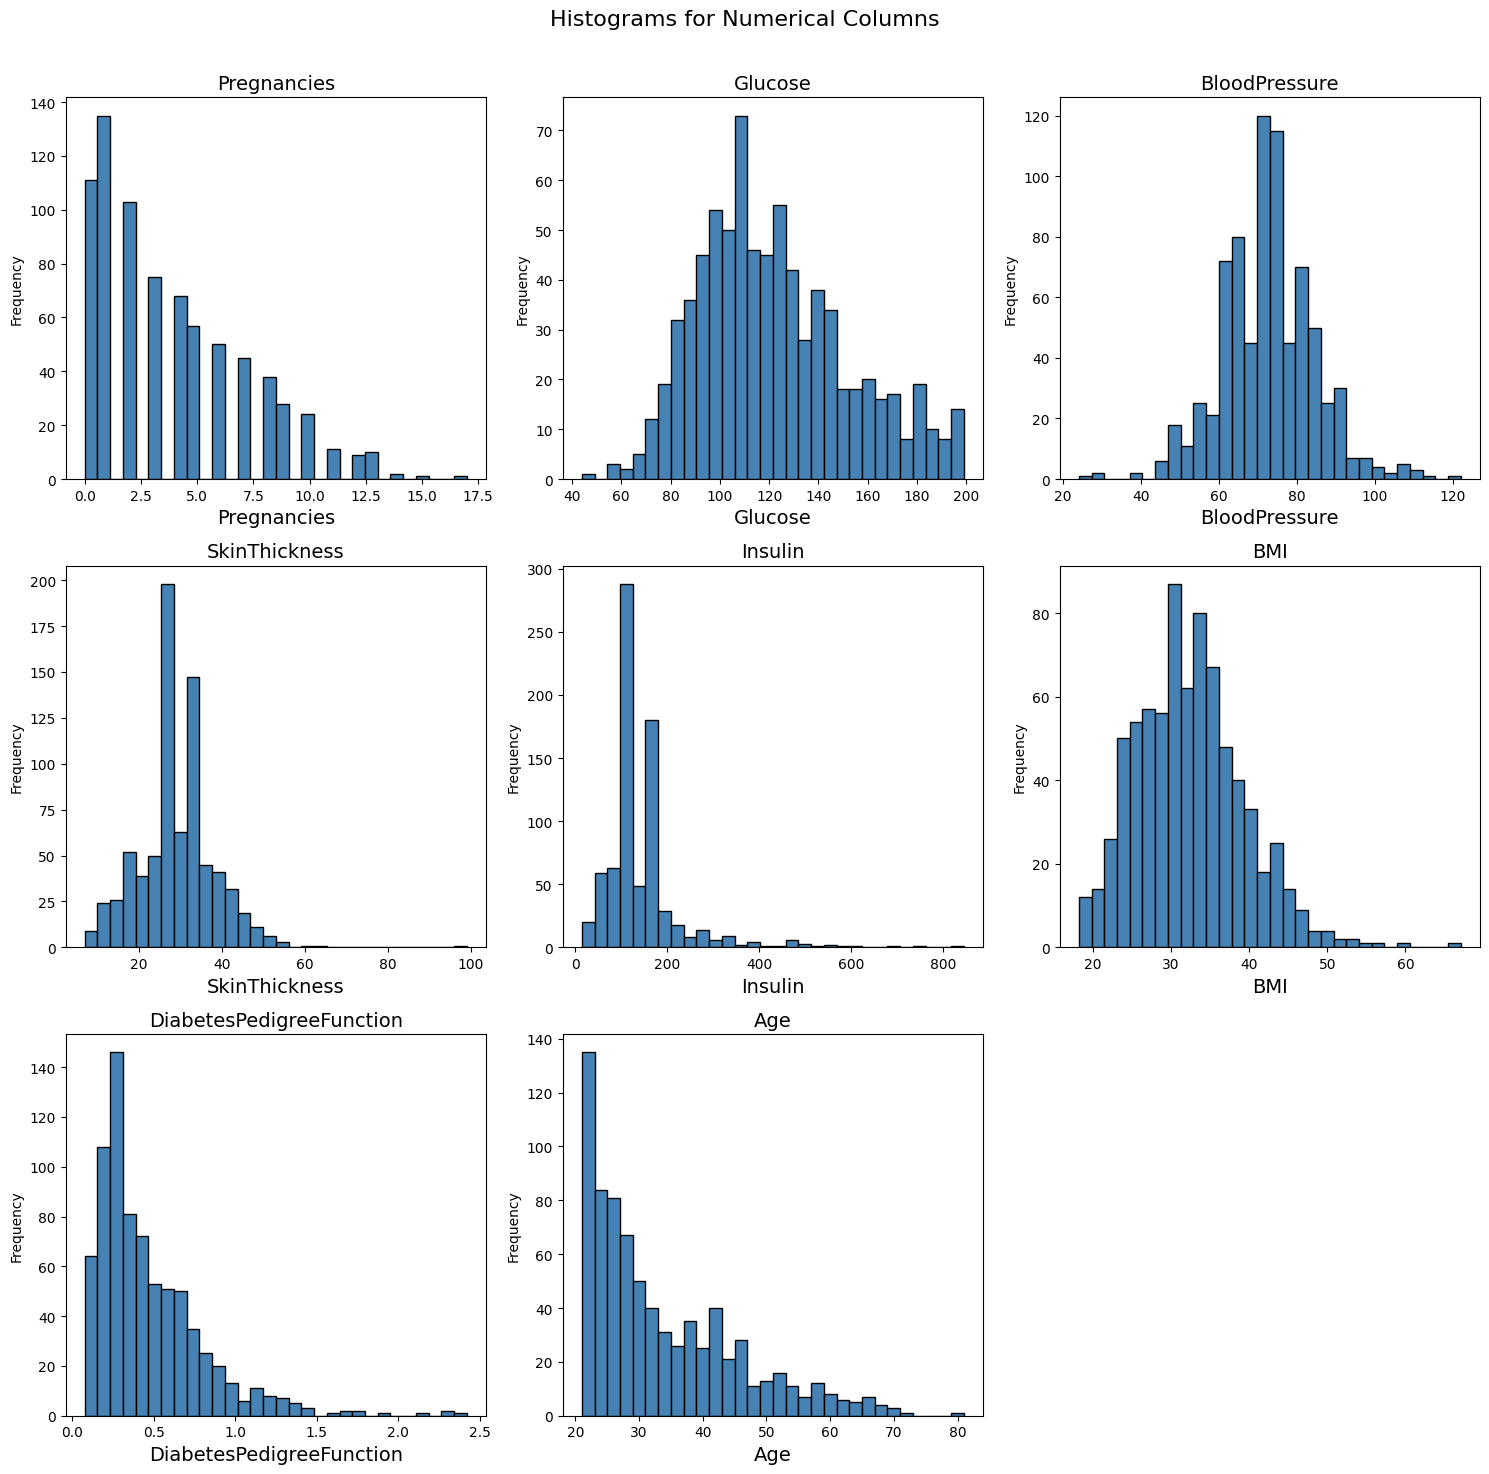

In [31]:
plot_histograms(df, X, title='Histograms for Numerical Columns')

# Skewness of features

In [32]:
# 📊 Print skewness for each numerical column in your DataFrame
print("📈 Skewness of each column:\n")
print(df[X].skew().sort_values(ascending=False))

📈 Skewness of each column:

Insulin                     3.028046
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Pregnancies                 0.901674
SkinThickness               0.817477
BMI                         0.606416
Glucose                     0.532324
BloodPressure               0.140830
dtype: float64


# Remove outliers using z-score and IQR

In [33]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# Columns for IQR filtering
iqr_cols = ['Pregnancies', 'Insulin', 'DiabetesPedigreeFunction', 'Age']

# Columns for Z-score filtering (the rest of X)
zscore_cols = [col for col in X if col not in iqr_cols]

# --- IQR Filtering ---
iqr_mask = pd.Series([True] * len(df))
for col in iqr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_mask &= df[col].between(lower, upper)

# --- Z-score Filtering ---
z_scores = np.abs(zscore(df[zscore_cols]))
zscore_mask = (z_scores <= 3).all(axis=1)

# --- Combined Mask ---
combined_mask = iqr_mask & zscore_mask

# Apply the combined mask
df_no_outliers = df[combined_mask].reset_index(drop=True)

print(f"✅ Outliers removed: {len(df) - len(df_no_outliers)} rows dropped")


✅ Outliers removed: 101 rows dropped


In [34]:
# Check skewness of numerical columns after outlier removal
skew_values = df_no_outliers[X].skew()
print(skew_values)


Pregnancies                 0.828383
Glucose                     0.607425
BloodPressure               0.177852
SkinThickness               0.123061
Insulin                     0.367558
BMI                         0.374673
DiabetesPedigreeFunction    0.980083
Age                         1.057780
dtype: float64


In [35]:
df_no_outliers.count()

Pregnancies                 667
Glucose                     667
BloodPressure               667
SkinThickness               667
Insulin                     667
BMI                         667
DiabetesPedigreeFunction    667
Age                         667
Outcome                     667
dtype: int64

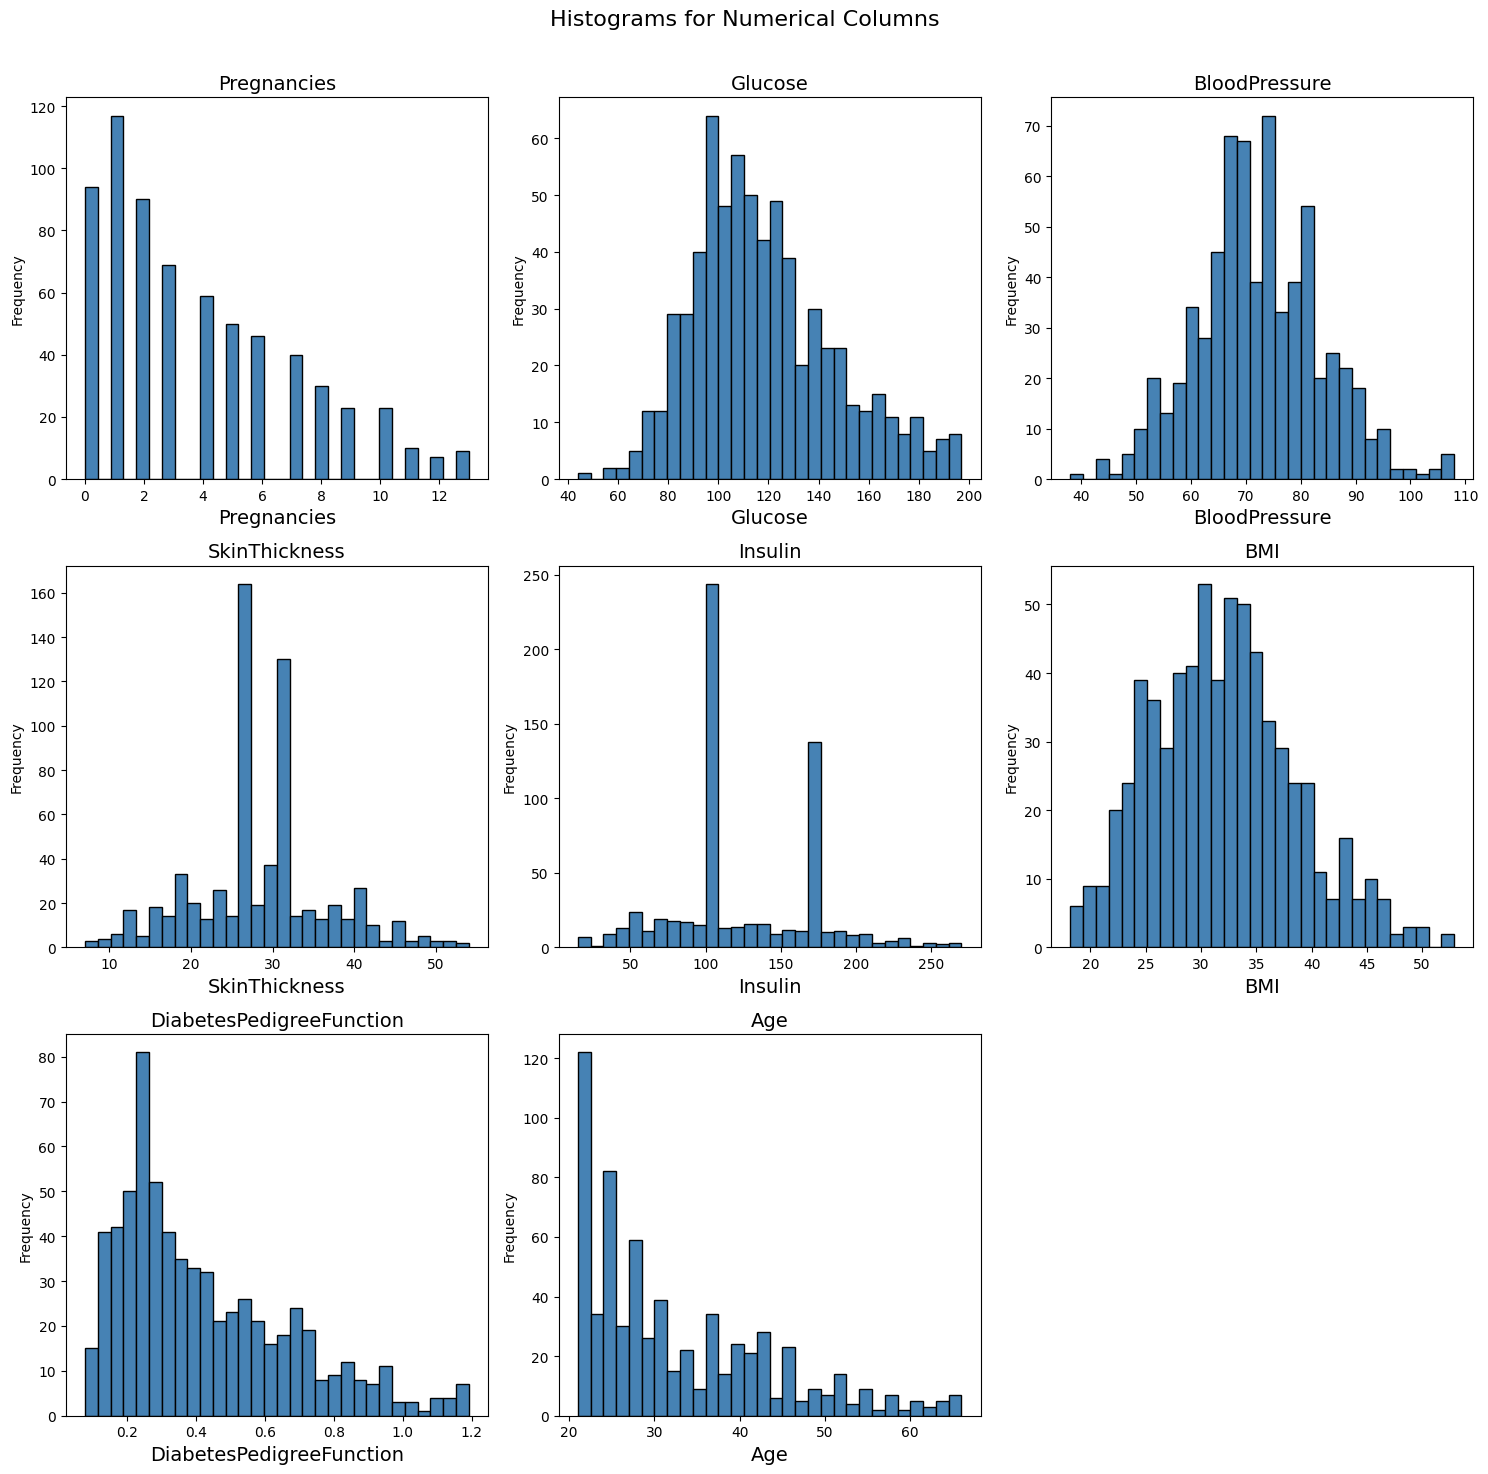

In [36]:
plot_histograms(df_no_outliers, X, title='Histograms for Numerical Columns')

# Pearson correlation heatmap

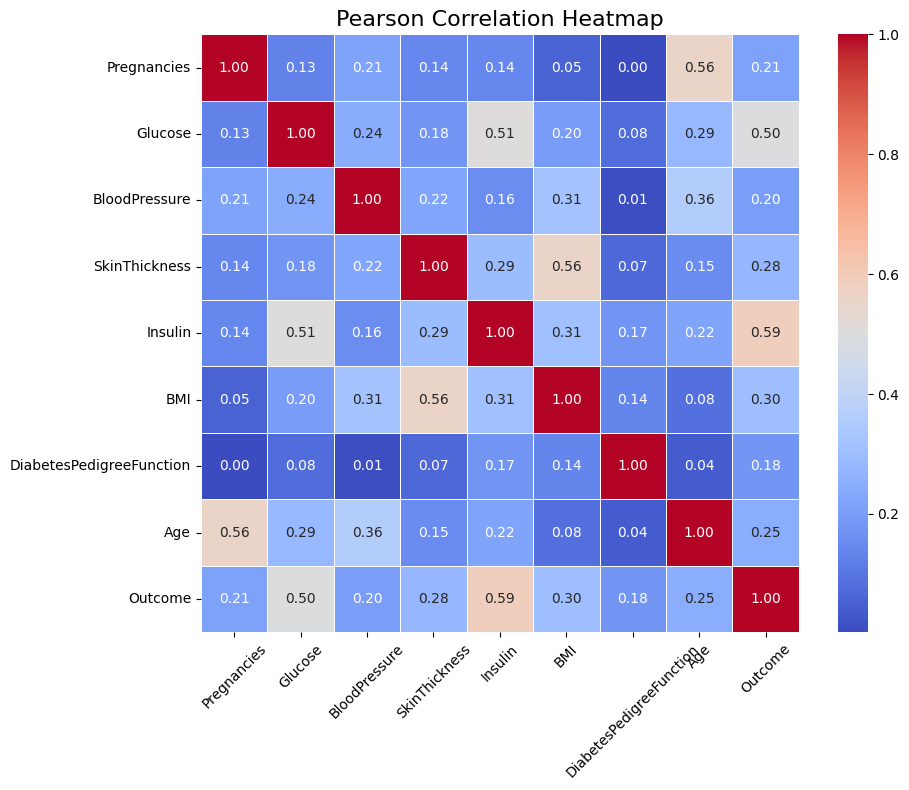

In [37]:
# Compute the Pearson correlation matrix
corr_matrix = df_no_outliers.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Train test split

In [38]:
from sklearn.model_selection import train_test_split

# Step 1: Separate features and target
X = df_no_outliers.drop(columns='Outcome')
y = df_no_outliers['Outcome']

# Step 2: Perform stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Optional: Print shapes to confirm
print("🧪 Dataset split:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")


🧪 Dataset split:
X_train: (533, 8), y_train: (533,)
X_test:  (134, 8), y_test:  (134,)


# Scaling

In [39]:
from sklearn.preprocessing import StandardScaler

# Step 3: Initialize the scaler
scaler = StandardScaler()

# Step 4: Fit on training data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# SMOTE 

In [40]:
from imblearn.over_sampling import SMOTE
# Step 5: Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# Optional: check class distribution after SMOTE
print("✅ Class distribution after SMOTE:")
print(y_train_sm.value_counts())


✅ Class distribution after SMOTE:
Outcome
0    363
1    363
Name: count, dtype: int64


# Model performance

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# Define models with default hyperparameters
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "kNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Store results
results = []

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_scaled)

    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score'],
        'AUC': auc
    })

# Convert to DataFrame and sort
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

# Get top 3 by F1-Score
top3_df = results_df.head(3)

# Display results
print("All Model Results:\n", results_df)
print("\nTop 3 Models by F1-Score:\n", top3_df)


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:36:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


All Model Results:
                  Model  Accuracy  Precision    Recall  F1-Score       AUC
7             AdaBoost  0.925373   0.923077  0.837209  0.878049  0.952466
5        Random Forest  0.917910   0.880952  0.860465  0.870588  0.949655
8              XGBoost  0.917910   0.921053  0.813953  0.864198  0.967544
6    Gradient Boosting  0.910448   0.897436  0.813953  0.853659  0.967289
2                  SVM  0.888060   0.804348  0.860465  0.831461  0.901610
3          Naive Bayes  0.880597   0.787234  0.860465  0.822222  0.917199
4                  kNN  0.873134   0.782609  0.837209  0.808989  0.907105
0  Logistic Regression  0.865672   0.777778  0.813953  0.795455  0.899310
1        Decision Tree  0.850746   0.794872  0.720930  0.756098  0.816509

Top 3 Models by F1-Score:
            Model  Accuracy  Precision    Recall  F1-Score       AUC
7       AdaBoost  0.925373   0.923077  0.837209  0.878049  0.952466
5  Random Forest  0.917910   0.880952  0.860465  0.870588  0.949655
8       

# Finetune

In [48]:
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# 1. Setup CV strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. AdaBoost tuning with BayesSearchCV using F1-score
ab_search = BayesSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    search_spaces={
        'n_estimators': Integer(50, 300),
        'learning_rate': Real(0.01, 1.0, prior='log-uniform')
    },
    cv=cv_strategy,
    n_iter=30,
    scoring='f1',  # <-- Optimizing for F1-score
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

# 3. Fit the model
ab_search.fit(X_train_sm, y_train_sm)

# 4. Print all iterations & highlight the best
print(f"\n📊 Iteration Progress for AdaBoost:")
ab_results_df = pd.DataFrame(ab_search.cv_results_).sort_values(by="mean_test_score", ascending=False).reset_index(drop=True)

for i, row in ab_results_df.iterrows():
    prefix = "⭐" if i == 0 else "  "
    print(f"{prefix} Iteration {i+1:2}: F1 = {row['mean_test_score']:.4f}, Params = {row['params']}")

print(f"\n✅ Best AdaBoost Params: {ab_search.best_params_}")
print(f"✅ Best F1 Score: {ab_search.best_score_:.4f}\n")

# 5. Evaluate tuned AdaBoost model on test set
best_ab_model = ab_search.best_estimator_
y_pred_ab = best_ab_model.predict(X_test_scaled)
y_proba_ab = best_ab_model.predict_proba(X_test_scaled)[:, 1]

acc_ab = accuracy_score(y_test, y_pred_ab)
auc_ab = roc_auc_score(y_test, y_proba_ab)
report_ab = classification_report(y_test, y_pred_ab, output_dict=True)

# 6. Create DataFrame row for tuned AdaBoost
tuned_ab_row = pd.DataFrame([{
    'Model': 'AdaBoost (Tuned)',
    'Accuracy': acc_ab,
    'Precision': report_ab['1']['precision'],
    'Recall': report_ab['1']['recall'],
    'F1-Score': report_ab['1']['f1-score'],
    'AUC': auc_ab
}])

# 7. Append to top3_df (assumes top3_df already exists)
top3_df = pd.concat([top3_df, tuned_ab_row], ignore_index=True)

# 9. Display updated top 3 + tuned model
print("\n🏅 Top 3 + Tuned AdaBoost Comparison:\n", top3_df)


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



📊 Iteration Progress for AdaBoost:
⭐ Iteration  1: F1 = 0.8971, Params = OrderedDict({'learning_rate': 0.07756486208064789, 'n_estimators': 280})
   Iteration  2: F1 = 0.8971, Params = OrderedDict({'learning_rate': 0.07107274763926634, 'n_estimators': 300})
   Iteration  3: F1 = 0.8958, Params = OrderedDict({'learning_rate': 0.13753989959874585, 'n_estimators': 167})
   Iteration  4: F1 = 0.8944, Params = OrderedDict({'learning_rate': 0.06932234757001524, 'n_estimators': 300})
   Iteration  5: F1 = 0.8941, Params = OrderedDict({'learning_rate': 0.07013387187449766, 'n_estimators': 300})
   Iteration  6: F1 = 0.8938, Params = OrderedDict({'learning_rate': 0.20954968529670304, 'n_estimators': 128})
   Iteration  7: F1 = 0.8930, Params = OrderedDict({'learning_rate': 0.11926141640580022, 'n_estimators': 207})
   Iteration  8: F1 = 0.8925, Params = OrderedDict({'learning_rate': 0.18265196410353887, 'n_estimators': 182})
   Iteration  9: F1 = 0.8921, Params = OrderedDict({'learning_rate': 

In [49]:
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# 1. Setup CV strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Random Forest tuning with BayesSearchCV using F1-score
rf_search = BayesSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    search_spaces={
        'n_estimators': Integer(100, 400),
        'max_depth': Integer(5, 30),
        'min_samples_split': Integer(2, 20),
        'min_samples_leaf': Integer(1, 10),
        'max_features': Real(0.1, 1.0),
        'bootstrap': [True, False],
        'min_impurity_decrease': Real(0.0, 0.1),
        'max_leaf_nodes': Integer(10, 100)
    },
    cv=cv_strategy,
    n_iter=30,
    scoring='f1',  # Optimizing for F1-score
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

# 3. Fit the model
rf_search.fit(X_train_sm, y_train_sm)

# 4. Print all iterations & highlight the best
print(f"\n📊 Iteration Progress for Random Forest:")
rf_results_df = pd.DataFrame(rf_search.cv_results_).sort_values(by="mean_test_score", ascending=False).reset_index(drop=True)

for i, row in rf_results_df.iterrows():
    prefix = "⭐" if i == 0 else "  "
    print(f"{prefix} Iteration {i+1:2}: F1 = {row['mean_test_score']:.4f}, Params = {row['params']}")

print(f"\n✅ Best Random Forest Params: {rf_search.best_params_}")
print(f"✅ Best F1 Score: {rf_search.best_score_:.4f}\n")

# 5. Evaluate tuned Random Forest model on test set
best_rf_model = rf_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_scaled)
y_proba_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# 6. Create DataFrame row for tuned Random Forest
tuned_rf_row = pd.DataFrame([{
    'Model': 'Random Forest (Tuned)',
    'Accuracy': acc_rf,
    'Precision': report_rf['1']['precision'],
    'Recall': report_rf['1']['recall'],
    'F1-Score': report_rf['1']['f1-score'],
    'AUC': auc_rf
}])

# 7. Append to top3_df
top3_df = pd.concat([top3_df, tuned_rf_row], ignore_index=True)

# 9. Display updated top3_df with tuned Random Forest
print("\n🏅 Top 3 + Tuned Random Forest Comparison:\n", top3_df)



📊 Iteration Progress for Random Forest:
⭐ Iteration  1: F1 = 0.8991, Params = OrderedDict({'bootstrap': True, 'max_depth': 18, 'max_features': 0.5182781103112416, 'max_leaf_nodes': 43, 'min_impurity_decrease': 0.0014863803685682302, 'min_samples_leaf': 1, 'min_samples_split': 12, 'n_estimators': 246})
   Iteration  2: F1 = 0.8984, Params = OrderedDict({'bootstrap': False, 'max_depth': 5, 'max_features': 0.1, 'max_leaf_nodes': 49, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 400})
   Iteration  3: F1 = 0.8980, Params = OrderedDict({'bootstrap': True, 'max_depth': 7, 'max_features': 0.13639218132750683, 'max_leaf_nodes': 37, 'min_impurity_decrease': 0.0028401910734737086, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 269})
   Iteration  4: F1 = 0.8970, Params = OrderedDict({'bootstrap': False, 'max_depth': 10, 'max_features': 0.1, 'max_leaf_nodes': 100, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_spli

In [50]:
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# 1. Setup CV strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. XGBoost tuning with BayesSearchCV using F1-score
xgb_search = BayesSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    search_spaces={
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(3, 15),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'subsample': Real(0.5, 1.0),
        'colsample_bytree': Real(0.5, 1.0)
    },
    cv=cv_strategy,
    n_iter=30,
    scoring='f1',  # Optimizing for F1-score
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

# 3. Fit the model
xgb_search.fit(X_train_sm, y_train_sm)

# 4. Print all iterations & highlight the best
print(f"\n📊 Iteration Progress for XGBoost:")
xgb_results_df = pd.DataFrame(xgb_search.cv_results_).sort_values(by="mean_test_score", ascending=False).reset_index(drop=True)

for i, row in xgb_results_df.iterrows():
    prefix = "⭐" if i == 0 else "  "
    print(f"{prefix} Iteration {i+1:2}: F1 = {row['mean_test_score']:.4f}, Params = {row['params']}")

print(f"\n✅ Best XGBoost Params: {xgb_search.best_params_}")
print(f"✅ Best F1 Score: {xgb_search.best_score_:.4f}\n")

# 5. Evaluate tuned XGBoost model on test set
best_xgb_model = xgb_search.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test_scaled)
y_proba_xgb = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

# 6. Create DataFrame row for tuned XGBoost
tuned_xgb_row = pd.DataFrame([{
    'Model': 'XGBoost (Tuned)',
    'Accuracy': acc_xgb,
    'Precision': report_xgb['1']['precision'],
    'Recall': report_xgb['1']['recall'],
    'F1-Score': report_xgb['1']['f1-score'],
    'AUC': auc_xgb
}])

# 7. Append to top3_df
top3_df = pd.concat([top3_df, tuned_xgb_row], ignore_index=True)

# 9. Display updated top3_df with tuned XGBoost
print("\n🏅 Top 3 + Tuned XGBoost Comparison:\n", top3_df)


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:49:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



📊 Iteration Progress for XGBoost:
⭐ Iteration  1: F1 = 0.9132, Params = OrderedDict({'colsample_bytree': 0.9972593693200422, 'learning_rate': 0.08757656738444825, 'max_depth': 10, 'n_estimators': 140, 'subsample': 0.8636454298565344})
   Iteration  2: F1 = 0.9120, Params = OrderedDict({'colsample_bytree': 0.9950074707457695, 'learning_rate': 0.06798015994192212, 'max_depth': 13, 'n_estimators': 225, 'subsample': 0.8765434454272991})
   Iteration  3: F1 = 0.9103, Params = OrderedDict({'colsample_bytree': 1.0, 'learning_rate': 0.29999999999999993, 'max_depth': 9, 'n_estimators': 61, 'subsample': 0.8173651769837469})
   Iteration  4: F1 = 0.9095, Params = OrderedDict({'colsample_bytree': 0.8830735199416888, 'learning_rate': 0.03698136049194377, 'max_depth': 14, 'n_estimators': 281, 'subsample': 0.9043544581560339})
   Iteration  5: F1 = 0.9095, Params = OrderedDict({'colsample_bytree': 0.8997767208035865, 'learning_rate': 0.04436313425678925, 'max_depth': 9, 'n_estimators': 229, 'subsamp

In [51]:
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd

# Stratified K-Fold setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------- 1. AdaBoost --------
ab_search = BayesSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    search_spaces={
        'n_estimators': Integer(50, 300),
        'learning_rate': Real(0.01, 1.0, prior='log-uniform')
    },
    cv=cv_strategy,
    n_iter=30,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)
ab_search.fit(X_train_sm, y_train_sm)

# -------- 2. Random Forest --------
rf_search = BayesSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    search_spaces={
        'n_estimators': Integer(100, 400),
        'max_depth': Integer(5, 30),
        'min_samples_split': Integer(2, 20),
        'min_samples_leaf': Integer(1, 10),
        'max_features': Real(0.1, 1.0),
        'bootstrap': [True, False],
        'min_impurity_decrease': Real(0.0, 0.1),
        'max_leaf_nodes': Integer(10, 100)
    },
    cv=cv_strategy,
    n_iter=30,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)
rf_search.fit(X_train_sm, y_train_sm)

# -------- 3. XGBoost --------
xgb_search = BayesSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    search_spaces={
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(3, 15),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'subsample': Real(0.5, 1.0),
        'colsample_bytree': Real(0.5, 1.0)
    },
    cv=cv_strategy,
    n_iter=30,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)
xgb_search.fit(X_train_sm, y_train_sm)

# -------- Print Iteration Logs --------
def print_search_progress(search_obj, model_name):
    print(f"\n📊 Iteration Progress for {model_name}:")
    results_df = pd.DataFrame(search_obj.cv_results_)
    for i, row in results_df.iterrows():
        print(f"Iteration {i+1:2}: AUC = {row['mean_test_score']:.4f}, Params = {row['params']}")

    print(f"✅ Best {model_name} Params:\n", search_obj.best_params_)
    print(f"✅ Best AUC Score: {search_obj.best_score_:.4f}\n")

print_search_progress(ab_search, "AdaBoost")
print_search_progress(rf_search, "Random Forest")
print_search_progress(xgb_search, "XGBoost")


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:57:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



📊 Iteration Progress for AdaBoost:
Iteration  1: AUC = 0.9548, Params = OrderedDict({'learning_rate': 0.06610098295419149, 'n_estimators': 232})
Iteration  2: AUC = 0.9443, Params = OrderedDict({'learning_rate': 0.4729080547055919, 'n_estimators': 271})
Iteration  3: AUC = 0.9568, Params = OrderedDict({'learning_rate': 0.07756486208064789, 'n_estimators': 280})
Iteration  4: AUC = 0.9436, Params = OrderedDict({'learning_rate': 0.42149456283334996, 'n_estimators': 93})
Iteration  5: AUC = 0.9437, Params = OrderedDict({'learning_rate': 0.3972893133963027, 'n_estimators': 160})
Iteration  6: AUC = 0.9513, Params = OrderedDict({'learning_rate': 0.29380287142759304, 'n_estimators': 285})
Iteration  7: AUC = 0.9542, Params = OrderedDict({'learning_rate': 0.1714583803805369, 'n_estimators': 244})
Iteration  8: AUC = 0.9558, Params = OrderedDict({'learning_rate': 0.12212543829922852, 'n_estimators': 280})
Iteration  9: AUC = 0.9366, Params = OrderedDict({'learning_rate': 0.8146216961026963, '

In [52]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# Define fine-tuned models
tuned_models = {
    "Tuned AdaBoost": ab_search.best_estimator_,
    "Tuned Random Forest": rf_search.best_estimator_,
    "Tuned XGBoost": xgb_search.best_estimator_,
}

# Store tuned results
tuned_results = []

for name, model in tuned_models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)

    tuned_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score'],
        'AUC': auc
    })

# Convert to DataFrame
tuned_df = pd.DataFrame(tuned_results).sort_values(by="F1-Score", ascending=False)

# Concatenate for comparison
comparison_df = pd.concat([top3_df, tuned_df], ignore_index=True)

# Display
print("🆚 Comparison: Top 3 Default Models vs Fine-Tuned Models")
print(comparison_df)


c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:57:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


🆚 Comparison: Top 3 Default Models vs Fine-Tuned Models
                   Model  Accuracy  Precision    Recall  F1-Score       AUC
0               AdaBoost  0.925373   0.923077  0.837209  0.878049  0.952466
1          Random Forest  0.917910   0.880952  0.860465  0.870588  0.949655
2                XGBoost  0.917910   0.921053  0.813953  0.864198  0.967544
3       AdaBoost (Tuned)  0.925373   0.923077  0.837209  0.878049  0.964733
4  Random Forest (Tuned)  0.917910   0.880952  0.860465  0.870588  0.954766
5        XGBoost (Tuned)  0.902985   0.894737  0.790698  0.839506  0.968566
6         Tuned AdaBoost  0.925373   0.923077  0.837209  0.878049  0.967289
7    Tuned Random Forest  0.917910   0.880952  0.860465  0.870588  0.959111
8          Tuned XGBoost  0.917910   0.921053  0.813953  0.864198  0.971122


In [219]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# Get best estimators
best_rf = rf_search.best_estimator_
best_ab = ab_search.best_estimator_
best_xgb = xgb_search.best_estimator_

# Store results
finetuned_results = []

# Evaluate each model
for name, model in {
    "Random Forest (Tuned)": best_rf,
    "AdaBoost (Tuned)": best_ab,
    "XGBoost (Tuned)": best_xgb
}.items():
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)

    # Append results
    finetuned_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score'],
        'AUC': auc
    })

# Display results
finetuned_df = pd.DataFrame(finetuned_results).sort_values(by="F1-Score", ascending=False)
print(finetuned_df)


                   Model  Accuracy  Precision    Recall  F1-Score       AUC
1       AdaBoost (Tuned)  0.917910   0.900000  0.837209  0.867470  0.968566
0  Random Forest (Tuned)  0.910448   0.878049  0.837209  0.857143  0.950038
2        XGBoost (Tuned)  0.902985   0.894737  0.790698  0.839506  0.968566


# Feature importance

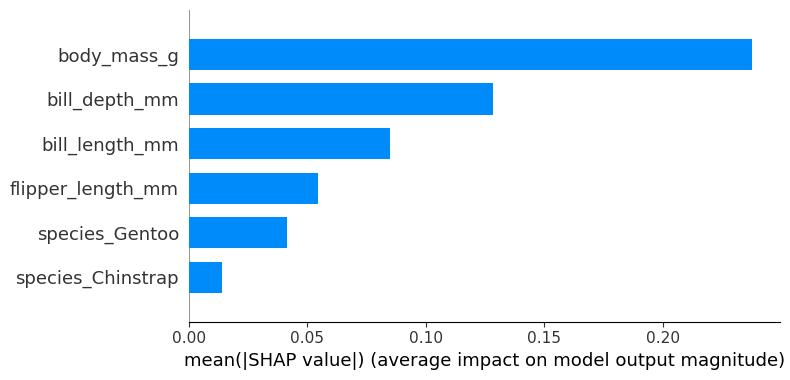

# SHAP?


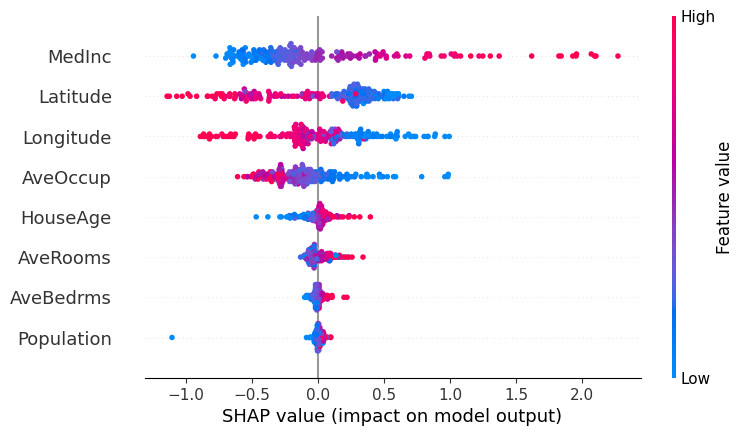

# Feature engineering

## Glucose

In [188]:
# Step 1: Define the classification function
def classify_glucose(val):
    if val < 100:
        return "Normal"
    elif 100 <= val < 126:
        return "Prediabetes"
    else:
        return "Diabetes"

## Blood pressure

In [189]:
# Step 1: Define classification function
def classify_bp(bp):
    if bp < 80:
        return "Normal"
    elif 80 <= bp < 90:
        return "Hypertension_Stage_1"
    else:
        return "Hypertension_Stage_2"

## Insulin

In [190]:
# Step 1: Define classification function
def classify_insulin(insulin):
    if insulin <= 16:
        return "Low"
    elif 16 < insulin <= 166:
        return "Normal"
    else:
        return "High"


## BMI

In [191]:
# Step 1: Define the classification function
def classify_bmi(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi <= 24.9:
        return "Healthy"
    elif 25.0 <= bmi <= 29.9:
        return "Overweight"
    else:
        return "Obese"


In [192]:
# Step 2: Apply feature engineering to both X_train_sm and X_test
def apply_feature_engineering(df):
    df = df.copy()

    # Glucose classification
    df["Glucose_Class"] = df["Glucose"].apply(classify_glucose)

    # Blood Pressure classification
    df["BloodPressure_Class"] = df["BloodPressure"].apply(classify_bp)

    # Insulin classification
    df["Insulin_Class"] = df["Insulin"].apply(classify_insulin)

    # BMI classification
    df["BMI_Class"] = df["BMI"].apply(classify_bmi)

    # One-hot encode the newly created class columns
    df = pd.get_dummies(df, columns=[
        "Glucose_Class", 
        "BloodPressure_Class", 
        "Insulin_Class", 
        "BMI_Class"
    ], prefix_sep="_")

    return df

# Step 3: Apply to both training and test sets
X_train_fe = apply_feature_engineering(X_train_sm)
X_test_fe = apply_feature_engineering(X_test)


In [193]:
X_train_fe

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_Class_Diabetes,Glucose_Class_Normal,...,BloodPressure_Class_Hypertension_Stage_1,BloodPressure_Class_Hypertension_Stage_2,BloodPressure_Class_Normal,Insulin_Class_High,Insulin_Class_Low,Insulin_Class_Normal,BMI_Class_Healthy,BMI_Class_Obese,BMI_Class_Overweight,BMI_Class_Underweight
0,1,106.000000,70.000000,28.000000,135.00000,34.200000,0.142000,22,False,False,...,False,False,True,False,False,True,False,True,False,False
1,3,174.000000,58.000000,22.000000,194.00000,32.900000,0.593000,36,True,False,...,False,False,True,True,False,False,False,True,False,False
2,5,189.000000,64.000000,33.000000,325.00000,31.200000,0.583000,29,True,False,...,False,False,True,True,False,False,False,True,False,False
3,0,91.000000,68.000000,32.000000,210.00000,39.900000,0.381000,25,False,True,...,False,False,True,True,False,False,False,True,False,False
4,9,184.000000,85.000000,15.000000,169.50000,30.000000,1.213000,49,True,False,...,True,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,4,109.000000,63.780011,43.670016,102.29984,34.909995,0.861992,25,False,False,...,False,False,True,False,False,True,False,True,False,False
758,2,136.365966,71.520978,32.000000,169.50000,29.271795,0.616021,24,True,False,...,False,False,True,True,False,False,False,False,True,False
759,1,146.000000,72.809877,32.000000,169.50000,31.406063,0.275305,28,True,False,...,False,False,True,True,False,False,False,True,False,False
760,8,184.939819,84.342126,16.597693,169.50000,29.389117,1.111124,49,True,False,...,True,False,False,True,False,False,False,False,True,False


In [194]:
X_test_fe

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_Class_Diabetes,Glucose_Class_Normal,Glucose_Class_Prediabetes,BloodPressure_Class_Hypertension_Stage_1,BloodPressure_Class_Hypertension_Stage_2,BloodPressure_Class_Normal,Insulin_Class_High,Insulin_Class_Normal,BMI_Class_Healthy,BMI_Class_Obese,BMI_Class_Overweight
629,8,91.0,82.0,27.0,102.5,35.6,0.587,68,False,True,False,True,False,False,False,True,False,True,False
262,7,161.0,86.0,32.0,169.5,30.4,0.165,47,True,False,False,True,False,False,True,False,False,True,False
344,3,81.0,86.0,16.0,66.0,27.5,0.306,22,False,True,False,True,False,False,False,True,False,False,True
618,1,199.0,76.0,43.0,169.5,42.9,1.394,22,True,False,False,False,False,True,True,False,False,True,False
335,1,196.0,76.0,36.0,249.0,36.5,0.875,29,True,False,False,False,False,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,0,95.0,80.0,45.0,92.0,36.5,0.330,26,False,True,False,True,False,False,False,True,False,True,False
418,0,120.0,74.0,18.0,63.0,30.5,0.285,26,False,False,True,False,False,True,False,True,False,True,False
691,1,102.0,74.0,32.0,169.5,39.5,0.293,42,False,False,True,False,False,True,True,False,False,True,False
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,True,False,False,False,False,True,True,False,True,False,False
